In [1]:
import os

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image, PIL.ImageFont, PIL.ImageDraw
import tensorflow as tf
import tensorflow_datasets as tfds

In [3]:
im_width = 75
im_height = 75
use_normalized_coordinates = True

def draw_bounding_boxes_on_image_array(image, boxes, color=[], thickness=1, display_str_list=()):
    image_pil = PIL.Image.fromarray(image)
    rgbimg = PIL.Image.new("RGBA", image_pil.size)
    rgbimg.paste(image_pil)
    draw_bounding_boxes_on_image(rgbimg, boxes, color, thickness, display_str_list)
    return np.array(rgbimg)

def draw_bounding_boxes_on_image(image, boxes, color=[], thickness=1, display_str_list=()):
    boxes_shape = boxes.shape
    if not boxes_shape:
        return
    if len(boxes_shape) != 2 or boxes_shape[1] != 4:
        raise ValueError('Input must be of size [N,4]')
    for i in range(boxes_shape[0]):
        draw_bounding_box_on_image(image, boxes[i, 0], boxes[i, 1], boxes[i, 2], boxes[i, 3], color[i],
                                    thickness, display_str_list[i])

def draw_bounding_box_on_image(image, ymin, xmin, ymax, xmax, color='red', thickness=1, display_str_list=None, use_normalized_coordinates=True):
    draw = PIL.ImageDraw.Draw(image)
    im_width, im_height = image.size
    if use_normalized_coordinates:
        (left, right, top, bottom) = (xmin * im_width, xmax * im_width, ymin * im_height, ymax * im_height)
    else:
        (left, right, top, bottom) = (xmin, xmax, ymin, ymax)

    draw.line([(left, top), (left, bottom), (right, bottom), (right, top), (left, top)], 
               width=thickness, fill=color)


In [4]:
def dataset_to_numpy_util(training_dataset, validation_dataset, N):
    batch_train_ds = training_dataset.unbatch().batch(N)

    if tf.executing_eagerly():
        for validation_digits, (validation_labels, validation_bboxes) in validation_dataset:
            validation_digits = validation_digits.numpy()
            validation_labels = validation_labels.numpy()
            validation_bboxes = validation_bboxes.numpy()
            break

        for training_digits, (training_labels, training_bboxes) in training_dataset:
            training_digits = training_digits.numpy()
            training_labels = training_labels.numpy()
            training_bboxes = training_bboxes.numpy()
            break

    validation_labels = np.argmax(validation_labels, axis=1)
    training_labels = np.argmax(training_labels, axis=1)
    
    return (training_digits, training_labels, training_bboxes,
            validation_digits, validation_labels, validation_bboxes)


In [5]:
MATPLOILIB_FONT_DIR = os.path.join(os.path.dirname(plt.__file__), 'mpl-data/fonts/ttf')

def create_digits_from_local_fonts(n):
    font_labels = []
    img = PIL.Image.new('LA', (75*n, 75), color = (0,255))
    font1 = PIL.ImageFont.truetype(os.path.join(MATPLOILIB_FONT_DIR, 'DejaVuSansMono-Oblique.ttf'), 25)
    font2 = PIL.ImageFont.truetype(os.path.join(MATPLOILIB_FONT_DIR, 'STIXGeneral.ttf'), 25)
    d = PIL.ImageDraw.Draw(img)
    for i in range(n):
        font_labels.append(i % 10)
        d.text((7+i*75, 0 if i < 10 else -4), str(i % 10), fill=(255,255), font=font1 if i < 10 else font2)
    font_digits = np.array(img.getdata(), np.float32)[:,0] / 255.0
    font_digits = np.reshape(np.stack(np.split(np.reshape(font_digits, [75, 75*n]), n, axis=1), axis=0), [n, 75*75])
    return font_digits, font_labels

In [6]:
def display_digits_with_boxes(digits, predictions, labels, pred_bboxes, bboxes, iou, title):
    n = 10
    indexes = np.random.choice(len(predictions), size=n)
    n_digits = digits[indexes]
    n_predictions = predictions[indexes]
    n_labels = labels[indexes]

    n_iou = []
    if len(iou) > 0:
        n_iou = iou[indexes]

    if len(pred_bboxes) > 0:
        n_pred_bboxes = pred_bboxes[indexes]

    if len(bboxes) > 0:
        n_bboxes = bboxes[indexes]

    n_digits = n_digits * 255.0
    n_digits = n_digits.reshape(n, 75, 75)
    fig = plt.figure(figsize=(20, 4))
    plt.title(title)
    plt.xticks([])
    plt.yticks([])

    for i in range(n):
        ax = fig.add_subplot(1, n, i+1)
        bboxes_to_plot = []
        if len(pred_bboxes) > i:
            bboxes_to_plot.append(n_pred_bboxes[i])
            
        if len(bboxes) > i:
            bboxes_to_plot.append(n_bboxes[i])

        img_to_draw = draw_bounding_boxes_on_image_array(image=n_digits[i], boxes=np.asarray(bboxes_to_plot),
                                                       color=['red', 'green'], display_str_list=['True', 'Pred'])
        plt.xlabel(n_predictions[i])
        plt.xticks([])
        plt.yticks([])

        if n_predictions[i] != n_labels[i]:
            ax.xaxis.label.set_color('red')

        plt.imshow(img_to_draw)

        if len(iou) > 1:
            color = "black"
            if n_iou[i][0] < iou_threshold:
                color = "red"
            ax.text(0.2, -0.3, "IoU: %s" % (n_iou[i][0]), color=color, transform=ax.transAxes)
            

In [7]:
def plot_metrics(metric_name, title):
    plt.title(title)
    plt.plot(history.history[metric_name], color='blue', label=metric_name)
    plt.plot(history.history['val_' + metric_name], color='green', label='val_' + metric_name)
   



In [8]:
strategy = tf.distribute.get_strategy()
strategy.num_replicas_in_sync

1

In [9]:
BATCH_SIZE = 64 * strategy.num_replicas_in_sync

In [10]:
def read_image_tfds(image, label):
    xmin = tf.random.uniform((), 0, 48, dtype=tf.int32)
    ymin = tf.random.uniform((), 0, 48, dtype=tf.int32)
    image = tf.reshape(image, (28, 28, 1))
    image = tf.image.pad_to_bounding_box(image, ymin, xmin, 75, 75)
    image = tf.cast(image, tf.float32) / 255.0
    xmin = tf.cast(xmin, tf.float32)
    ymin = tf.cast(ymin, tf.float32)

    xmax = (xmin + 28) / 75
    ymax = (ymin + 28) / 75
    xmin = xmin / 75
    ymin = ymin / 75

    return image, (tf.one_hot(label, 10), [xmin, ymin, xmax, ymax])


In [11]:
def get_training_dataset():
    
    with strategy.scope():
        dataset = tfds.load("mnist", split="train", as_supervised=True, try_gcs=True)
        dataset = dataset.map(read_image_tfds, num_parallel_calls=16)
        dataset = dataset.shuffle(5000, reshuffle_each_iteration=True)
        dataset = dataset.repeat()
        dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
        dataset = dataset.prefetch(-1)
    return dataset

In [12]:
def get_validation_dataset():
    
    with strategy.scope():
        dataset = tfds.load("mnist", split="test", as_supervised=True, try_gcs=True)  # Changed "train" to "test" for validation
        dataset = dataset.map(read_image_tfds, num_parallel_calls=16)
        dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)  # Changed from 100000 to BATCH_SIZE
        dataset = dataset.repeat()
    return dataset

In [13]:
with strategy.scope():
    training_dataset = get_training_dataset()
    validation_dataset = get_validation_dataset()

In [14]:
(training_digits, training_labels, training_bboxes,
 validation_digits, validation_labels, validation_bboxes) = dataset_to_numpy_util(training_dataset, validation_dataset, 10)

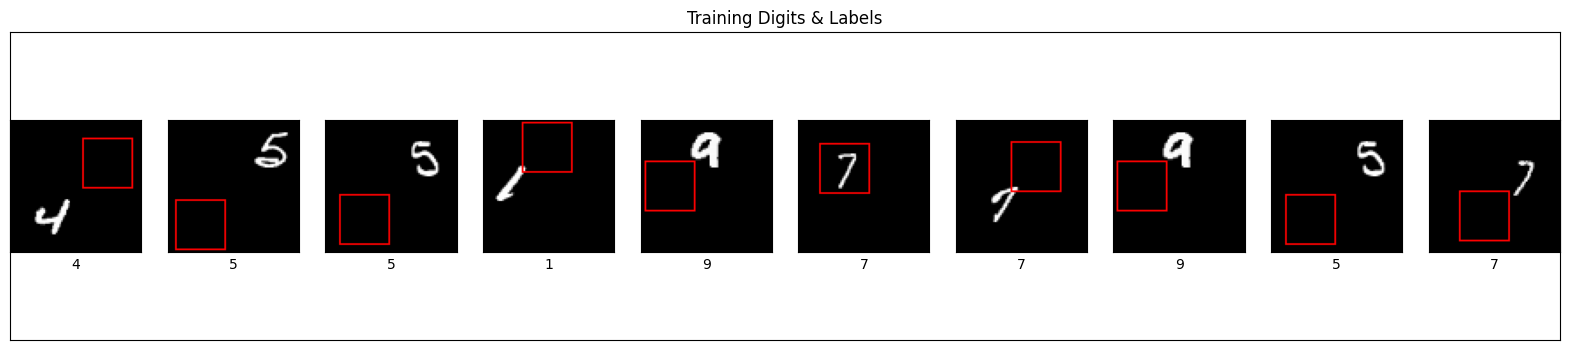

In [15]:
display_digits_with_boxes(training_digits, training_labels,
                         training_labels, np.array([]), training_bboxes,
                         np.array([]), "Training Digits & Labels")

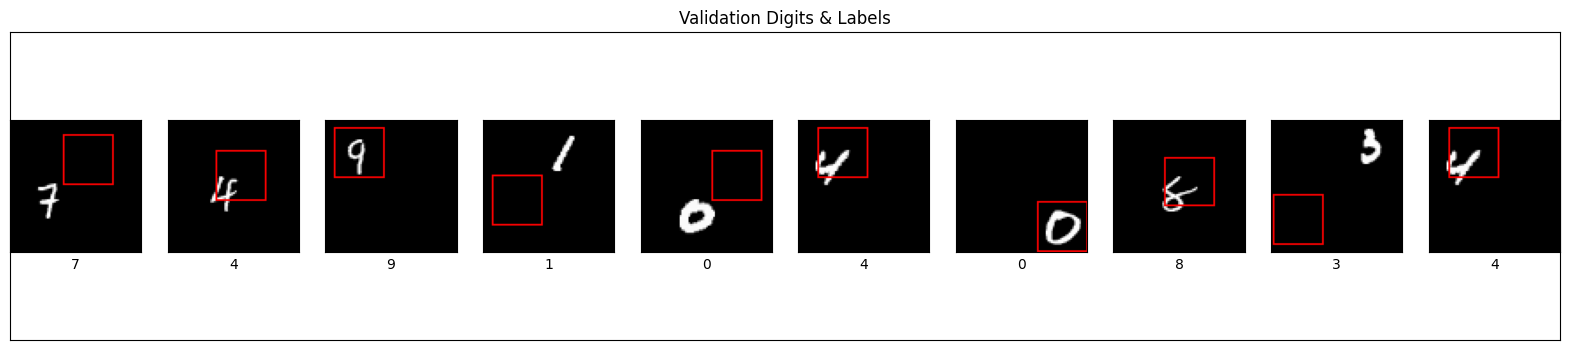

In [16]:
display_digits_with_boxes(validation_digits, validation_labels,
                         validation_labels, np.array([]), validation_bboxes,
                         np.array([]), "Validation Digits & Labels")

In [17]:
# 4: Define the Network
def feature_extractor(inputs):
    x = tf.keras.layers.Conv2D(64, activation='relu', kernel_size=1, input_shape=(75,75,1))(inputs)
    x = tf.keras.layers.MaxPooling2D(2,3)(x)
    x = tf.keras.layers.Conv2D(64, activation='relu', kernel_size=3)(x)
    x = tf.keras.layers.MaxPooling2D(2,3)(x)
    x = tf.keras.layers.Conv2D(64, activation='relu', kernel_size=3)(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    return x

In [18]:
def dense_layers(inputs):
    x = tf.keras.layers.Flatten()(inputs)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    return x

In [19]:
def classifier(inputs):
    classification_output = tf.keras.layers.Dense(10, activation='softmax', name='classification')(inputs)
    return classification_output

In [20]:
def bounding_box_regression(inputs):
    bounding_box_output = tf.keras.layers.Dense(4, name="bounding_box")(inputs)
    return bounding_box_output

In [21]:
def final_model(inputs):
    feature_output = feature_extractor(inputs)
    dense_output = dense_layers(feature_output)
    classification_output = classifier(dense_output)
    bounding_box_output = bounding_box_regression(dense_output)
    
    model = tf.keras.Model(
        inputs=inputs,
        outputs=[classification_output, bounding_box_output]
    )
    return model

In [22]:
def define_and_compile_model(inputs):
    model = final_model(inputs)
    model.compile(
        optimizer='adam',
        loss={
            'classification': 'categorical_crossentropy',
            'bounding_box': 'mse'
        },
        metrics={
            'classification': 'accuracy',
            'bounding_box': 'mse'
        }
    )
    return model

In [23]:
with strategy.scope():
    inputs = tf.keras.layers.Input(shape=(75,75,1))
    model = define_and_compile_model(inputs)

model.summary()

C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 75, 75, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 75, 75, 64)        │             128 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 25, 25, 64)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 23, 23, 64)        │          36,928 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 8, 8, 64)          │               0 │ conv2d_1[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 6, 6, 64)          │          36,928 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 3, 3, 64)          │               0 │ conv2d_2[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 576)               │               0 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │          36,928 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classification (Dense)        │ (None, 10)                │             650 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bounding_box (Dense)          │ (None, 4)                 │             260 │ dense[0][0]                │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 111,822 (436.80 KB)

 Trainable params: 111,822 (436.80 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
EPOCHS = 20
steps_per_epoch = 60000 // BATCH_SIZE  # MNIST has 60,000 training samples

history = model.fit(
    training_dataset,
    steps_per_epoch=steps_per_epoch,  # Fixed from steps_per_epoch-steps_per_epoch
    validation_data=validation_dataset,
    validation_steps=1,
    epochs=EPOCHS
)

# Evaluate the model
loss, classification_loss, bounding_box_loss, classification_acc, bounding_box_mse = model.evaluate(
    validation_dataset,
    steps=1
)

print("\n---\n")
print(f"Validation Accuracy: {classification_acc:.4f}")
print(f"Bounding Box MSE: {bounding_box_mse:.4f}")
print("\n---\n")

Epoch 1/20
937/937 ━━━━━━━━━━━━━━━━━━━━ 173s 181ms/step - bounding_box_loss: 0.0246 - bounding_box_mse: 0.0246 - classification_accuracy: 0.6515 - classification_loss: 0.9960 - loss: 1.0206 - val_bounding_box_loss: 0.0135 - val_bounding_box_mse: 0.0135 - val_classification_accuracy: 0.8438 - val_classification_loss: 0.4978 - val_loss: 0.5113
Epoch 2/20
937/937 ━━━━━━━━━━━━━━━━━━━━ 168s 180ms/step - bounding_box_loss: 0.0088 - bounding_box_mse: 0.0088 - classification_accuracy: 0.8773 - classification_loss: 0.3854 - loss: 0.3942 - val_bounding_box_loss: 0.0084 - val_bounding_box_mse: 0.0084 - val_classification_accuracy: 0.8594 - val_classification_loss: 0.2918 - val_loss: 0.3002
Epoch 3/20
937/937 ━━━━━━━━━━━━━━━━━━━━ 175s 186ms/step - bounding_box_loss: 0.0053 - bounding_box_mse: 0.0053 - classification_accuracy: 0.9022 - classification_loss: 0.3095 - loss: 0.3148 - val_bounding_box_loss: 0.0068 - val_bounding_box_mse: 0.0068 - val_classification_accuracy: 0.9375 - val_classification_

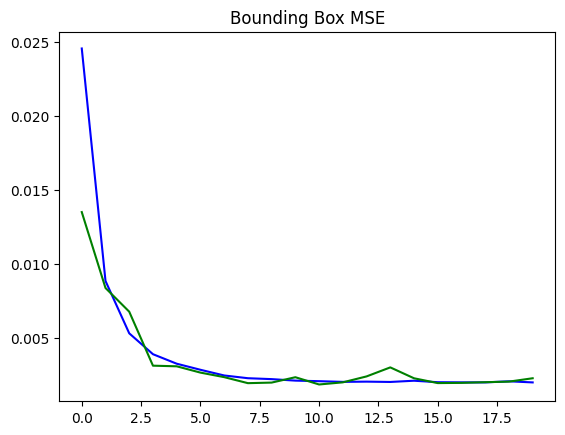

In [25]:
# Plot bounding box performance metrics
plot_metrics("bounding_box_loss", "Bounding Box MSE")  # Changed from "bounding_box_mse" to match typical Keras naming

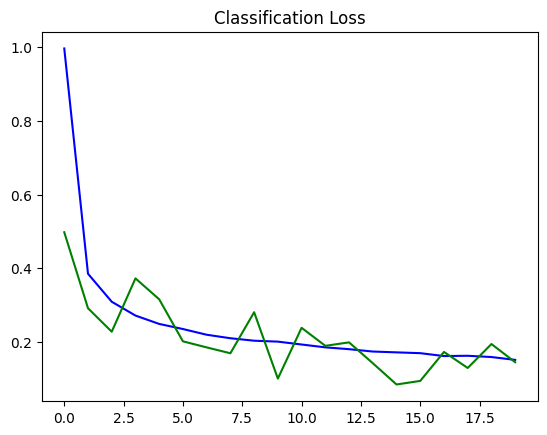

In [26]:
# Plot classification accuracy
plot_metrics("classification_loss", "Classification Loss")

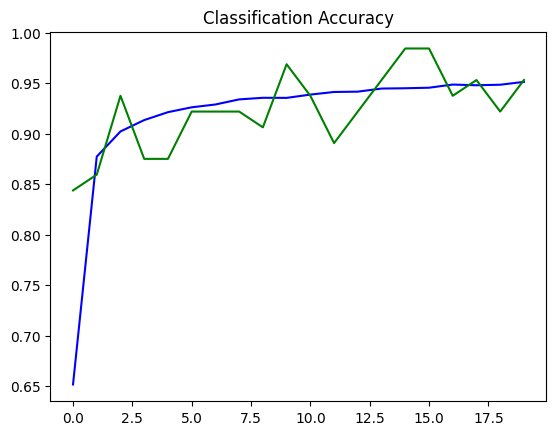

In [27]:
plot_metrics("classification_accuracy", "Classification Accuracy")

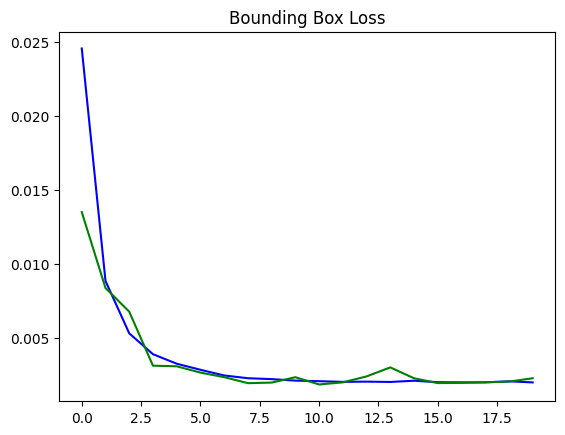

In [28]:
plot_metrics("bounding_box_loss", "Bounding Box Loss")

In [29]:
def intersection_over_union(pred_box, true_box):
    xmin_pred, ymin_pred, xmax_pred, ymax_pred = np.split(pred_box, 4, axis=1)
    xmin_true, ymin_true, xmax_true, ymax_true = np.split(true_box, 4, axis=1)

    smoothing_factor = 1e-10  # Corrected from 10-10 to 1e-10 (scientific notation)

    xmin_overlap = np.maximum(xmin_pred, xmin_true)
    xmax_overlap = np.minimum(xmax_pred, xmax_true)
    ymin_overlap = np.maximum(ymin_pred, ymin_true)
    ymax_overlap = np.minimum(ymax_pred, ymax_true)

    pred_box_area = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    true_box_area = (xmax_true - xmin_true) * (ymax_true - ymin_true)

    overlap_area = np.maximum((xmax_overlap - xmin_overlap), 0) * np.maximum((ymax_overlap - ymin_overlap), 0)
    union_area = (pred_box_area + true_box_area) - overlap_area

    iou = (overlap_area + smoothing_factor) / (union_area + smoothing_factor)  # Corrected 'low' to 'iou'
    return iou

In [30]:
# Make predictions on validation data
prediction = model.predict(validation_digits, batch_size=64)

predicted_labels = np.argmax(prediction[0], axis = 1)

prediction_bboxes = prediction[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


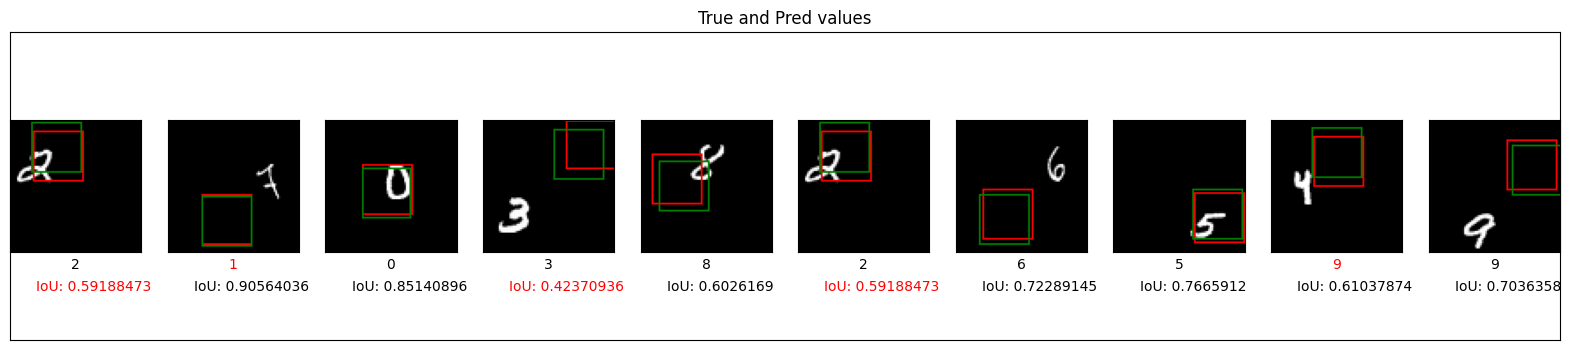

In [31]:
iou = intersection_over_union(prediction_bboxes,validation_bboxes)

iou_threshold = 0.6

display_digits_with_boxes(validation_digits,predicted_labels,validation_labels,prediction_bboxes,validation_bboxes,iou,"True and Pred values")